# Clustering the ECG Heartbeat Categorization Dataset
#### Assignment: Mahdi Ghadami

The ECG Heartbeat Categorization Dataset consists of labeled ECG heartbeat data from
12 different classes of heartbeats. The dataset contains various features derived from the
raw ECG signals. These features can be used for clustering purposes, even though the
data is labeled. The challenge is to explore different clustering methods on this dataset
and compare their effectiveness.

• Link to the dataset: https://www.kaggle.com/datasets/shayanfazeli/heartbeat

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shayanfazeli/heartbeat")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1


In [2]:
import warnings
warnings.filterwarnings('ignore')

# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# From kaggle:
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



## Preprocessing

* ### Reading data:

In [3]:
full_train = pd.read_csv('/root/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1/mitbih_train.csv')
full_test = pd.read_csv('/root/.cache/kagglehub/datasets/shayanfazeli/heartbeat/versions/1/mitbih_test.csv')
print("Dimension of train data frame:", full_train.shape)
print("Dimension of test data frame:", full_test.shape)


Dimension of train data frame: (87553, 188)
Dimension of test data frame: (21891, 188)


In [4]:
full_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87553 entries, 0 to 87552
Columns: 188 entries, 9.779411554336547852e-01 to 0.000000000000000000e+00.88
dtypes: float64(188)
memory usage: 125.6 MB


In [5]:
full_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21891 entries, 0 to 21890
Columns: 188 entries, 1.000000000000000000e+00 to 0.000000000000000000e+00.65
dtypes: float64(188)
memory usage: 31.4 MB


### missing values:

In [6]:
cols_with_missing = [col for col in full_train.columns if full_train[col].isnull().any()]
cols_with_missing

[]

In [7]:
full_test.isnull().sum().sum()

0

### categorical value, true dataset's lables:

In [8]:
low_cardinality_cols = [cname for cname in full_train.columns if full_train[cname].nunique() < 13
                                                                  or full_train[cname].dtype == "object"]
low_cardinality_cols

['0.000000000000000000e+00.88']

In [9]:
full_train[low_cardinality_cols[0]].unique()

array([0., 1., 2., 3., 4.])

In [10]:
column_index = full_train.columns.get_loc('0.000000000000000000e+00.88')
column_index

187

It seems like just "0.000000000000000000e+00.88" is the categorical data, which contains true labels, which are 5. It is the last feature.

### data imbalance:

In [11]:
full_train.iloc[:, 187].value_counts()

,count
0.000000000000000000e+00.88,
0.0,72470
4.0,6431
2.0,5788
1.0,2223
3.0,641


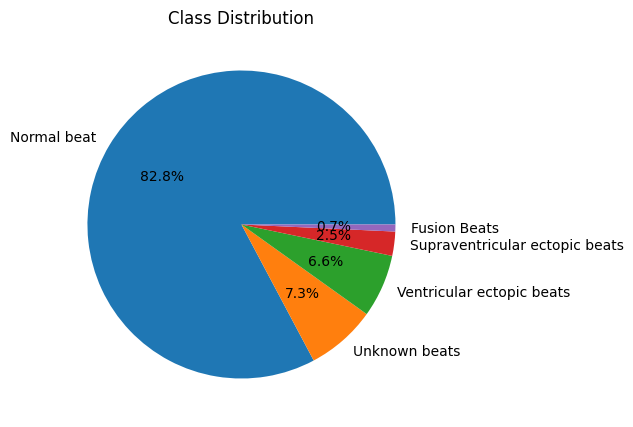

In [12]:
full_train.iloc[:, 187].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(10, 5),
    title="Class Distribution",
    labels=[
        "Normal beat",
        "Unknown beats",
        "Ventricular ectopic beats",
        "Supraventricular ectopic beats",
        "Fusion Beats"])
plt.ylabel("")
plt.show()

####Inference:
The data classes are imbalanced.
The Normal beats (0.0/N) class is overwhelmingly dominant, making up most of the data.

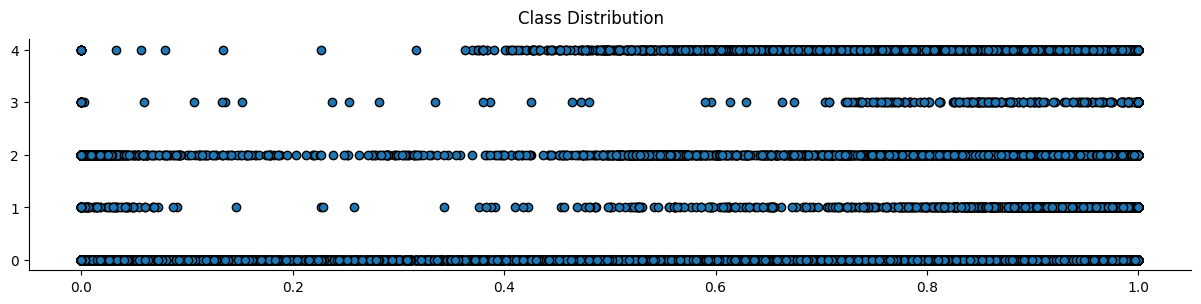

In [13]:
plt.figure(figsize=(15, 3))
kwarg_params = {'linewidth': 1, 'edgecolor': 'black'}
plt.scatter(full_train.iloc[:, 0], full_train.iloc[:, 187], **kwarg_params)
sns.despine()
plt.suptitle("Class Distribution")
plt.show()

### Scaling and Resampling:

In [14]:
from sklearn.preprocessing import StandardScaler

X = full_train.drop('0.000000000000000000e+00.88', axis=1)
y = full_train['0.000000000000000000e+00.88']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
from imblearn.over_sampling import KMeansSMOTE
from collections import Counter
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

desired_samples = 20000

over_strategy = {k: desired_samples for k, v in Counter(y).items() if v < desired_samples}
under_strategy = {k: desired_samples for k, v in Counter(y).items() if v > desired_samples}


under_sampler = RandomUnderSampler(sampling_strategy = under_strategy, random_state = 42)
over_sampler = KMeansSMOTE(sampling_strategy = over_strategy, cluster_balance_threshold=0.01, random_state = 42)


pipeline = Pipeline(steps=[('over', over_sampler), ('under', under_sampler)])

# Define Sample 1
X_resampled1, y_resampled1 = pipeline.fit_resample(X_scaled, y)

print("Before KMeansSMOTE:", Counter(y))
print("After KMeansSMOTE:", Counter(y_resampled1))

Before KMeansSMOTE: Counter({0.0: 72470, 4.0: 6431, 2.0: 5788, 1.0: 2223, 3.0: 641})
After KMeansSMOTE: Counter({2.0: 20006, 1.0: 20002, 4.0: 20002, 0.0: 20000, 3.0: 20000})


In [16]:
# CC
from imblearn.under_sampling import ClusterCentroids
from collections import Counter

cc = ClusterCentroids(random_state=42)
X_resampled2, y_resampled2 = cc.fit_resample(X_scaled, y)

print("Before ClusterCentroids:", Counter(y))
print("After ClusterCentroids:", Counter(y_resampled2))

Before ClusterCentroids: Counter({0.0: 72470, 4.0: 6431, 2.0: 5788, 1.0: 2223, 3.0: 641})
After ClusterCentroids: Counter({0.0: 641, 1.0: 641, 2.0: 641, 3.0: 641, 4.0: 641})


In [17]:
# Random over-sampling
from imblearn.over_sampling import RandomOverSampler

over_sampler = RandomOverSampler(sampling_strategy={3.0: 2000}, random_state=42)
pipeline = Pipeline([('random', over_sampler), ('kmeans_smote', KMeansSMOTE(random_state=42))])

X_resampled3, y_resampled3 = pipeline.fit_resample(X_scaled, y)
print("Before resampling:", Counter(y))
print("After resampling:", Counter(y_resampled3))

Before resampling: Counter({0.0: 72470, 4.0: 6431, 2.0: 5788, 1.0: 2223, 3.0: 641})
After resampling: Counter({2.0: 72472, 4.0: 72471, 0.0: 72470, 1.0: 72470, 3.0: 72470})


In [18]:
# Default SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled4, y_resampled4 = smote.fit_resample(X_scaled, y)

print("Before SMOTE:", Counter(y))
print("After SMOTE:", Counter(y_resampled4))

Before SMOTE: Counter({0.0: 72470, 4.0: 6431, 2.0: 5788, 1.0: 2223, 3.0: 641})
After SMOTE: Counter({0.0: 72470, 1.0: 72470, 2.0: 72470, 3.0: 72470, 4.0: 72470})


In [19]:
# Combine Undersample majority & Oversample minority
undersample = ClusterCentroids(random_state=42)
oversample = KMeansSMOTE(random_state=42)

pipeline = Pipeline(steps=[('under', undersample), ('over', oversample)])

X_resampled5, y_resampled5 = pipeline.fit_resample(X_scaled, y)


print("Before resampling:", Counter(y))
print("After resampling:", Counter(y_resampled5))


Before resampling: Counter({0.0: 72470, 4.0: 6431, 2.0: 5788, 1.0: 2223, 3.0: 641})
After resampling: Counter({0.0: 641, 1.0: 641, 2.0: 641, 3.0: 641, 4.0: 641})


## PCA


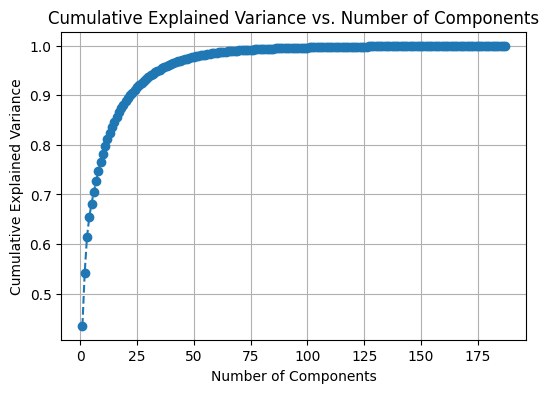


 Number of components to explain 90% variance: 23


In [20]:
from sklearn.decomposition import PCA

# Fit PCA to the data
pca = PCA()
pca.fit(X.values)

# Plot cumulative explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Find number of components for 90% variance
n_components_90 = next(i for i, cumsum in enumerate(cumulative_variance) if cumsum >= 0.90) + 1
print(f"\n Number of components to explain 90% variance: {n_components_90}")


In [21]:
# Fit PCA with optimal number of components
pca_90 = PCA(n_components=n_components_90)
X_reduced = pca_90.fit_transform(X)

# Reduced data
df_reduced = pd.DataFrame(X_reduced, columns=[f'PC{i+1}' for i in range(n_components_90)])
df_reduced.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23
0,-1.436901,0.604471,-0.569385,-0.413983,-0.194281,-0.380064,0.079089,-0.016608,-0.157492,-0.499966,...,-0.219039,-0.061628,-0.604224,-0.041497,-0.363421,-0.213966,0.222596,-0.060041,-0.026141,0.100117
1,-1.720589,-0.075125,-0.245867,0.075484,-0.677724,-0.350702,0.206937,-0.363524,0.383407,-0.029942,...,-0.075148,0.366449,-0.019399,-0.037236,-0.273840,-0.062698,0.409268,0.119990,-0.151683,-0.078130
2,-1.509371,-0.044757,0.349776,0.618407,-0.233999,-0.616878,0.102788,-0.204997,0.893532,0.132877,...,-0.412064,0.106112,-0.090728,-0.031622,-0.196144,0.131556,0.157937,0.404273,0.038415,0.055724
3,-1.181027,1.019874,-0.778778,-0.607433,-0.055793,-0.127347,0.542458,-0.036787,0.053439,-0.575759,...,-0.356831,0.402035,-0.554173,-0.182312,-0.271913,-0.380927,0.031674,-0.018475,0.112079,0.007085
4,1.629008,-0.054743,1.132460,0.074607,0.041044,-0.350011,-0.400459,-0.220828,-0.151351,-0.773638,...,-0.443626,-0.218061,0.065554,0.155662,-0.221429,0.172182,0.108894,-0.079248,0.163221,-0.226052


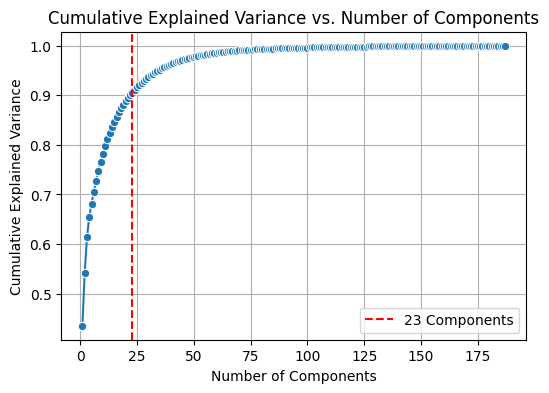

In [22]:
df_variance = pd.DataFrame({
    'Number of Components': range(1, len(explained_variance) + 1),
    'Cumulative Explained Variance': cumulative_variance
})

plt.figure(figsize=(6, 4))
sns.lineplot(data=df_variance, x='Number of Components', y='Cumulative Explained Variance', marker='o')
plt.axvline(x=n_components_90, color='r', linestyle='--', label=f'{n_components_90} Components')
plt.title('Cumulative Explained Variance vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

So we got best principle components and use them in next algorithms.

## K-Means Clustering

### Elbow, Determining The Optimal Number Of Clusters:

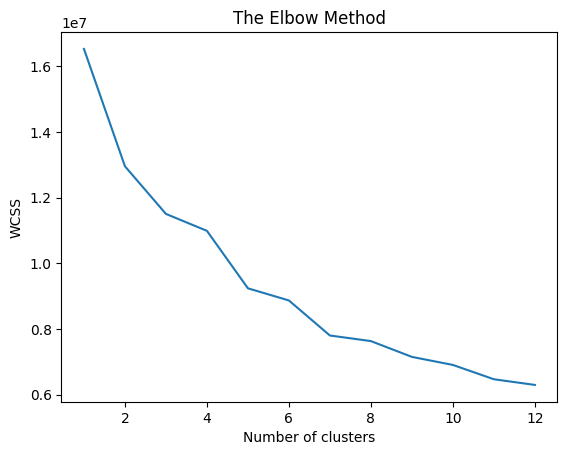

In [23]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 13):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X_resampled1)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 13), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

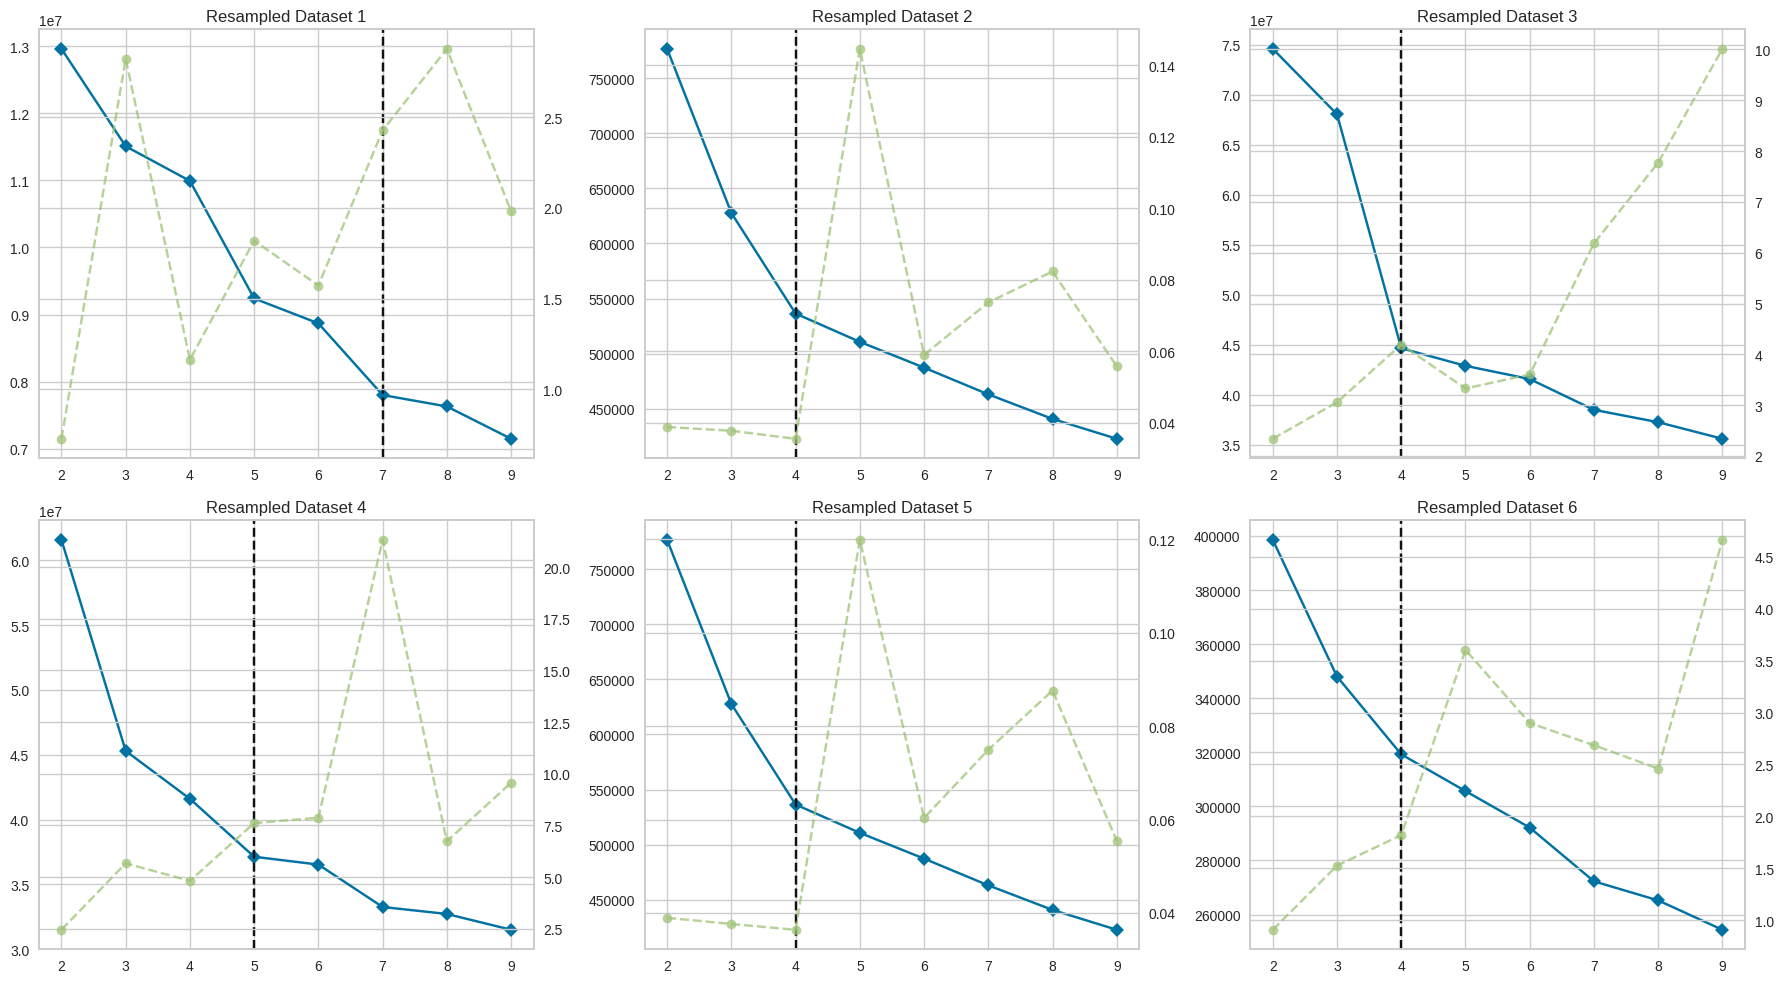

In [24]:
from yellowbrick.cluster import KElbowVisualizer

# Assuming six datasets
resampled_datasets = [X_resampled1, X_resampled2, X_resampled3, X_resampled4, X_resampled5, X]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (X_resampled, ax) in enumerate(zip(resampled_datasets, axes.flatten()), start=1):
    model = KMeans(random_state=42)
    visualizer = KElbowVisualizer(model, k=(2, 10), timings=True, ax=ax)

    visualizer.fit(X_resampled)
    ax.set_title(f'Resampled Dataset {i}')

plt.tight_layout()
plt.show()

### Model:

In [25]:
#Sample 1
X_kmeans = X_resampled1.copy()
kmeans = KMeans(n_clusters = 7, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X_kmeans)

In [26]:
df_kmeans = pd.DataFrame(X_resampled1)
df_kmeans['Cluster'] = kmeans.labels_
df_kmeans['Cluster'].value_counts()

,count
Cluster,
0,31955
2,16976
3,16377
1,15635
5,9350
6,7601
4,2116


In [27]:
#Sample 2
X_kmeans = X_resampled2.copy()
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X_kmeans)
df_kmeans = pd.DataFrame(X_resampled2)
df_kmeans['Cluster'] = kmeans.labels_
df_kmeans['Cluster'].value_counts()

,count
Cluster,
1,1258
3,756
4,739
0,242
2,210


In [28]:
#Sample 3
X_kmeans = X_resampled3.copy()
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X_kmeans)
df_kmeans = pd.DataFrame(X_resampled3)
df_kmeans['Cluster'] = kmeans.labels_
df_kmeans['Cluster'].value_counts()

,count
Cluster,
1,141153
3,120884
2,82132
0,18184


In [29]:
#Sample 4
X_kmeans = X_resampled4.copy()
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X_kmeans)
df_kmeans = pd.DataFrame(X_resampled4)
df_kmeans['Cluster'] = kmeans.labels_
df_kmeans['Cluster'].value_counts()

,count
Cluster,
1,183655
4,91634
3,61113
0,13744
2,12204


In [30]:
#Sample 5
X_kmeans = X_resampled5.copy()
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X_kmeans)
df_kmeans = pd.DataFrame(X_resampled5)
df_kmeans['Cluster'] = kmeans.labels_
df_kmeans['Cluster'].value_counts()

,count
Cluster,
1,1258
3,756
4,739
0,242
2,210


In [31]:
# orriginal dataset
X_kmeans = X.copy()
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X_kmeans)
df_kmeans = pd.DataFrame(X)
df_kmeans['Cluster'] = kmeans.labels_
df_kmeans['Cluster'].value_counts()

,count
Cluster,
3,42923
1,20399
0,16700
2,7531


#### Inference:
 It seems that best performance similar to real labels is Sample #1

In [32]:
X_kmeans = X_resampled1.copy()
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X_kmeans)
df_kmeans = pd.DataFrame(X_resampled1)
df_kmeans['Cluster'] = kmeans.labels_
df_kmeans['Cluster'].value_counts()

,count
Cluster,
0,33620
1,23528
2,21057
3,19704
4,2101


### Visualisation:

using PCA for finding best principle component to visualising in 2D.

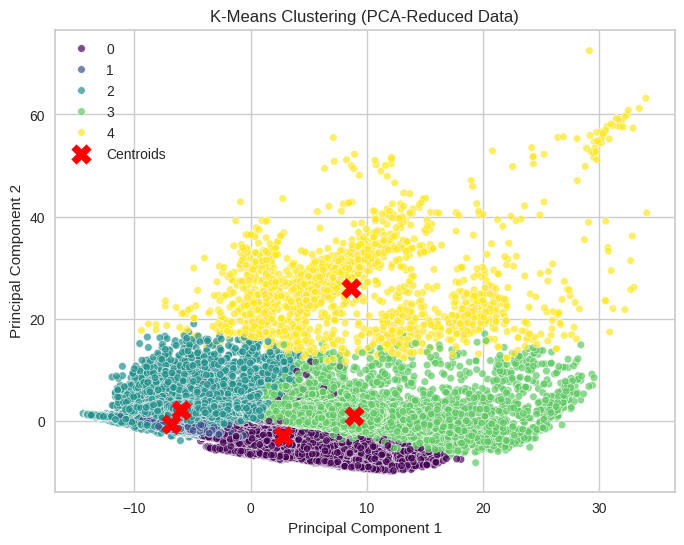

In [33]:
from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_resampled1)

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_kmeans, palette='viridis', s=30, alpha=0.7)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (PCA-Reduced Data)')
plt.legend()
plt.grid(True)
plt.show()

Compare with original dataset without resampling:

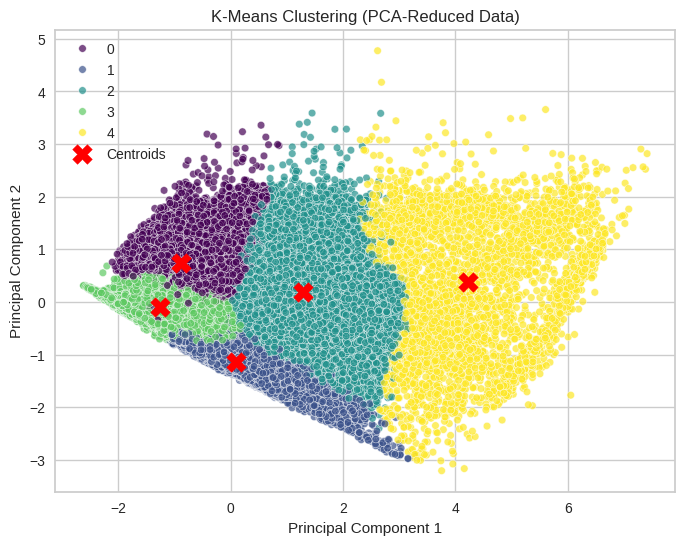

In [34]:
# K-Means
X_kmeans = X.copy()
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X_kmeans)
df_kmeans = pd.DataFrame(X)
df_kmeans['Cluster'] = kmeans.labels_
df_kmeans['Cluster'].value_counts()

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_kmeans, palette='viridis', s=30, alpha=0.7)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (PCA-Reduced Data)')
plt.legend()
plt.grid(True)
plt.show()

### PCA Reduced data:

Now we use reduced dataset which have 23 features that has been selected with PCA.

In [35]:
from sklearn.cluster import KMeans

X_kmeans = X_reduced.copy()
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X_kmeans)
df_kmeans = pd.DataFrame(X_reduced)
df_kmeans['Cluster'] = kmeans.labels_
df_kmeans['Cluster'].value_counts()

,count
Cluster,
0,32093
1,24354
4,18303
2,9071
3,3732


It seems that using reduced dataset has more affinity to the true lables.

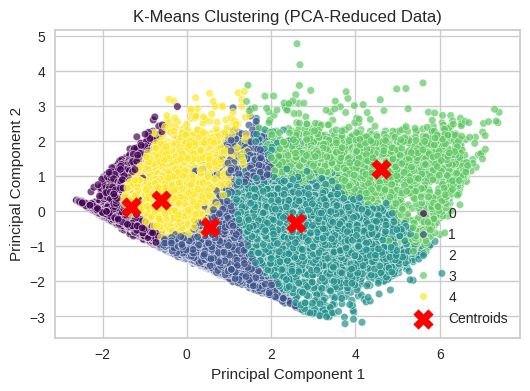

In [36]:
# Visualise
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_reduced)

# Scatter plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_kmeans, palette='viridis', s=30, alpha=0.7)

# Plot cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (PCA-Reduced Data)')
plt.legend()
plt.grid(True)
plt.show()

## Hierarchical Clustering

Due to the size of the samples and the slowness of the algorithm, we choose the second sample.

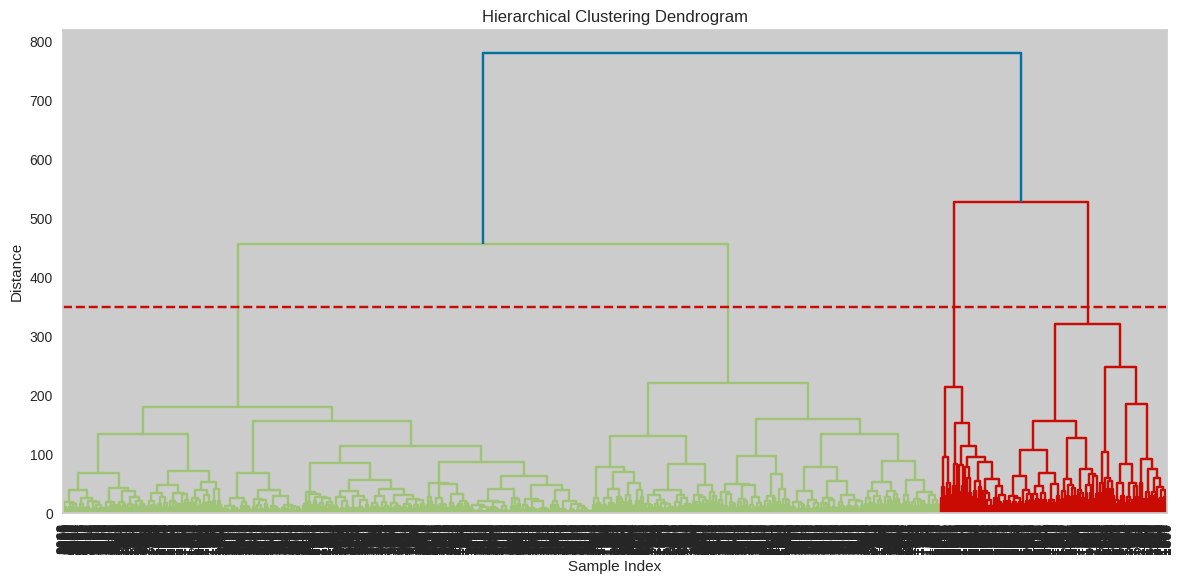

In [37]:
from scipy.cluster.hierarchy import dendrogram, linkage

df_agg = pd.DataFrame(X_resampled2)

linked = linkage(df_agg, method='ward', metric='euclidean')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='level', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)

plt.axhline(y=350, color='r', linestyle='--')

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

Red dashed line (plt.axhline) is adjusted to cut through the largest vertical gap. The number of vertical lines it intersects is the optimal number of clusters.
So it is 4.

In [38]:
# Agglomerative
from sklearn.cluster import AgglomerativeClustering

Agglomerative = AgglomerativeClustering(n_clusters = 4, metric = 'euclidean', linkage = 'ward')
y_Agglomerative = Agglomerative.fit_predict(df_agg)

df_agg['Cluster'] = y_Agglomerative
df_agg['Cluster'].value_counts()

,count
Cluster,
3,1538
1,1011
0,467
2,189


### Visualisation:

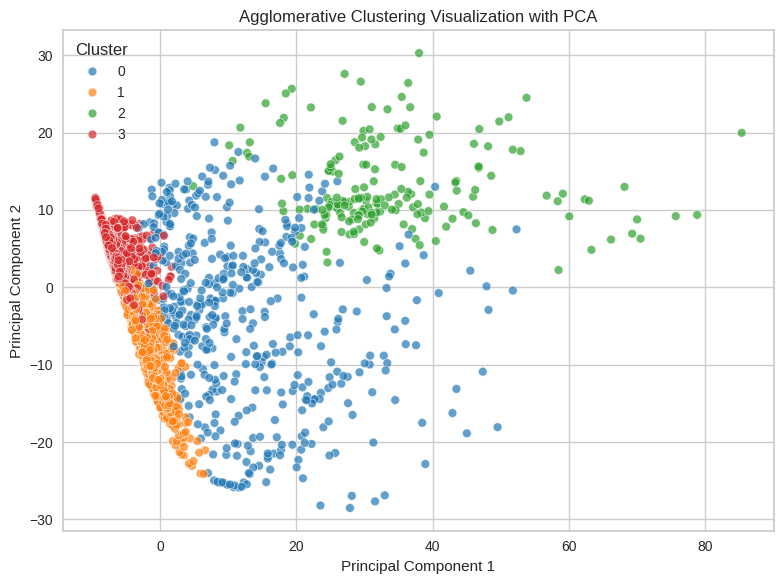

In [39]:
from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca_agg = pca.fit_transform(df_agg.drop('Cluster', axis=1))

df_pca_agg = pd.DataFrame(X_pca_agg, columns=['PCA1', 'PCA2'])
df_pca_agg['Cluster'] = df_agg['Cluster']

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca_agg, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=40, alpha=0.7)

plt.title('Agglomerative Clustering Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


### Inference:
It looks like almost the same plot as we have in k-means, but rotated -90.
PCA captures variance but doesn't preserve the orientation. So, the axes can flip or rotate, and the overall structure can still be the same.

* Both methods may identify similar cluster structures. However, Agglomerative Clustering is hierarchical and sensitive to linkage methods, while K-Means optimizes within-cluster variance.

* Because of computational complexity, for large datasets, K-Means is preferred due to speed. Agglomerative Clustering is more suitable for smaller datasets

* If the data contains outliers or noise, Agglomerative Clustering is generally more robust than K-Means.


## DBSCAN

Use elbow point in K-distance graph

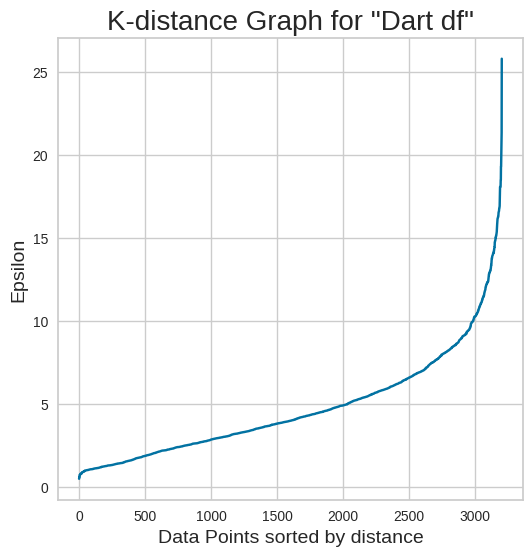

In [40]:
from sklearn.neighbors import NearestNeighbors

df_db = pd.DataFrame(X_resampled2)

nn = NearestNeighbors(n_neighbors=4)
nbrs = nn.fit(df_db)
distances, indices = nbrs.kneighbors(df_db)

# Plotting K-distance Graph
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(6,6))
plt.plot(distances)
plt.title('K-distance Graph for "Dart df"',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14)
plt.show()

We choose epsilon = 20 and start minPts from 188

In [41]:
from sklearn.cluster import DBSCAN

df_db = pd.DataFrame(X_resampled2)

dbscan = DBSCAN(eps=20, min_samples = 188, metric='euclidean')
y_DBScan = dbscan.fit_predict(df_db)

df_db['Cluster'] = y_DBScan
df_db['Cluster'].value_counts()

,count
Cluster,
0,2917
-1,288


### Visualising:

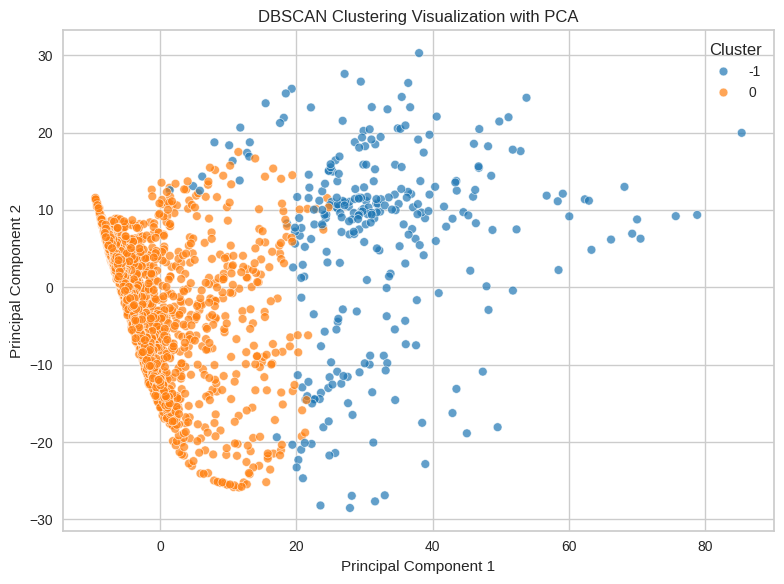

In [42]:
# Perform PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_db.drop(columns='Cluster'))

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df_db['Cluster']

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=40, alpha=0.7)

plt.title('DBSCAN Clustering Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

In [43]:
df_db = pd.DataFrame(X_resampled2)

dbscan = DBSCAN(eps = 7, min_samples = 13, metric='euclidean')
y_DBScan = dbscan.fit_predict(df_db)

df_db['Cluster'] = y_DBScan
df_db['Cluster'].value_counts()

,count
Cluster,
0,1971
-1,1135
3,38
2,31
1,30


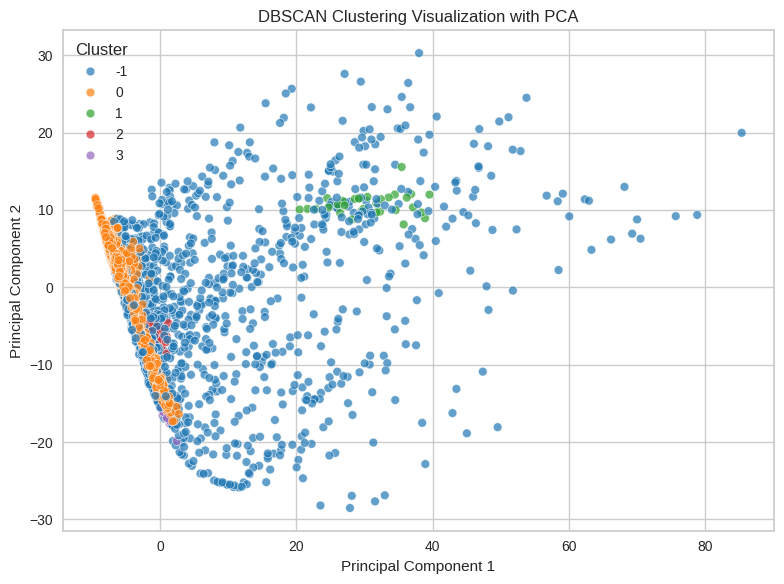

In [44]:
# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df_db.drop(columns='Cluster'))

df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df_db['Cluster']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Cluster', palette='tab10', s=40, alpha=0.7)

plt.title('DBSCAN Clustering Visualization with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

### Inference:
DBSCAN is particularly effective when dealing with datasets containing noise or outliers, while K-Means and Hierarchical Clustering are better for more homogeneous datasets.
Noise points in DBSCAN are never part of any cluster. This is a direct advantage over methods like K-Means, which assign all points to a cluster, even if they are far away from the centroids.